# Notebook 4: ML-Enhanced VaR — GARCH + XGBoost
## Volatility Clustering | Dynamic VaR | ML Exceedance Prediction

**Key insight:** Classical VaR assumes constant volatility — but financial markets exhibit **volatility clustering**: large moves cluster together. GARCH captures this.

**ML Layer:** XGBoost trained to predict next-day VaR exceedances using lagged returns, GARCH volatility, and macro features.

- **GARCH(1,1):** σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}
- **GJR-GARCH:** Adds asymmetry (leverage effect)
- **XGBoost:** Classifies whether tomorrow exceeds VaR threshold


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import pickle

try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ImportError:
    print('arch library not installed. Run: pip install arch')
    ARCH_AVAILABLE = False

try:
    import xgboost as xgb
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import roc_auc_score
    import shap
    ML_AVAILABLE = True
except ImportError:
    print('Install: pip install xgboost scikit-learn shap')
    ML_AVAILABLE = False

BASE_DIR    = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
DATA_DIR    = os.path.join(BASE_DIR, 'data')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')

portfolio_returns = pd.read_csv(os.path.join(DATA_DIR, 'portfolio_returns.csv'), index_col=0, parse_dates=True)['portfolio_return']
macro             = pd.read_csv(os.path.join(DATA_DIR, 'macro_factors.csv'), index_col=0, parse_dates=True)

CONFIDENCE_LEVEL = 0.99
ALPHA = 1 - CONFIDENCE_LEVEL
print('Data loaded.')

Data loaded.


In [2]:
# ── 1. Fit GARCH(1,1) and GJR-GARCH ─────────────────────────────────────────
if ARCH_AVAILABLE:
    returns_pct = portfolio_returns * 100

    garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1, dist='normal')
    garch_fit   = garch_model.fit(disp='off')

    gjr_model = arch_model(returns_pct, vol='Garch', p=1, o=1, q=1, dist='t')
    gjr_fit   = gjr_model.fit(disp='off')

    print('GARCH(1,1) parameters:')
    print(garch_fit.params.round(6))
    print(f'\nGARCH Log-Likelihood : {garch_fit.loglikelihood:.2f}')
    print(f'GJR-GARCH Log-Likelihood: {gjr_fit.loglikelihood:.2f}')
    print(f'GJR-GARCH BIC        : {gjr_fit.bic:.2f} (lower = better)')
else:
    print('Skipping GARCH — arch not installed')

GARCH(1,1) parameters:
mu          0.043042
omega       0.011899
alpha[1]    0.091901
beta[1]     0.893429
Name: params, dtype: float64

GARCH Log-Likelihood : -6326.15
GJR-GARCH Log-Likelihood: -6166.57
GJR-GARCH BIC        : 12384.86 (lower = better)


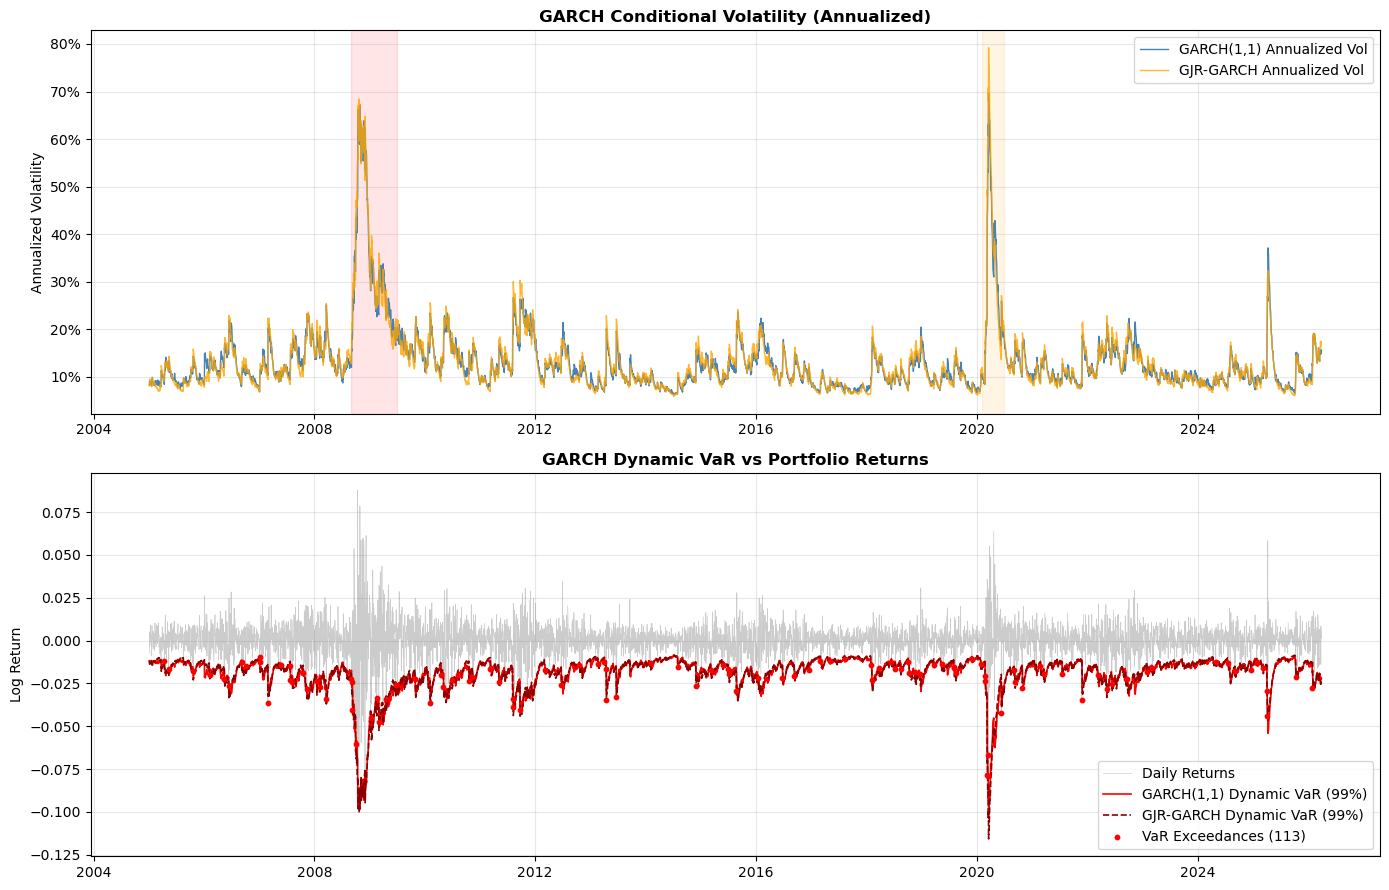

GARCH estimates saved.


In [3]:
# ── 2. GARCH-Based Dynamic VaR ────────────────────────────────────────────────
if ARCH_AVAILABLE:
    garch_vol = garch_fit.conditional_volatility / 100
    gjr_vol   = gjr_fit.conditional_volatility / 100

    z_alpha   = norm.ppf(ALPHA)
    garch_var = portfolio_returns.mean() + z_alpha * garch_vol
    gjr_var   = portfolio_returns.mean() + z_alpha * gjr_vol

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    ax = axes[0]
    ax.plot(garch_vol.index, garch_vol * np.sqrt(252), label='GARCH(1,1) Annualized Vol', color='steelblue', lw=1)
    ax.plot(gjr_vol.index,   gjr_vol   * np.sqrt(252), label='GJR-GARCH Annualized Vol',  color='orange',    lw=1, alpha=0.8)
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'), alpha=0.1, color='red')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-30'), alpha=0.1, color='orange')
    ax.set_title('GARCH Conditional Volatility (Annualized)', fontweight='bold')
    ax.set_ylabel('Annualized Volatility')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend()
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(portfolio_returns.index, portfolio_returns, color='gray', alpha=0.4, lw=0.5, label='Daily Returns')
    ax2.plot(garch_var.index, garch_var, color='red',     lw=1.2, label='GARCH(1,1) Dynamic VaR (99%)')
    ax2.plot(gjr_var.index,   gjr_var,   color='darkred', lw=1.2, linestyle='--', label='GJR-GARCH Dynamic VaR (99%)')
    exceedances = portfolio_returns[portfolio_returns < garch_var]
    ax2.scatter(exceedances.index, exceedances.values, color='red', s=10, zorder=5,
                label=f'VaR Exceedances ({len(exceedances)})')
    ax2.set_title('GARCH Dynamic VaR vs Portfolio Returns', fontweight='bold')
    ax2.set_ylabel('Log Return')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'fig7_garch_dynamic_var.png'), dpi=150, bbox_inches='tight')
    plt.show()

    garch_df = pd.DataFrame({'garch_vol': garch_vol, 'gjr_vol': gjr_vol,
                              'garch_var': garch_var, 'gjr_var': gjr_var})
    garch_df.to_csv(os.path.join(DATA_DIR, 'garch_estimates.csv'))
    print('GARCH estimates saved.')

In [4]:
# ── 3. Feature Engineering for ML ────────────────────────────────────────────
def build_features(portfolio_returns, macro, garch_vol=None):
    df = pd.DataFrame({'return': portfolio_returns})

    for lag in [1, 2, 3, 5, 10]:
        df[f'ret_lag{lag}'] = df['return'].shift(lag)

    df['vol_5d']   = df['return'].rolling(5).std()
    df['vol_21d']  = df['return'].rolling(21).std()
    df['vol_63d']  = df['return'].rolling(63).std()
    df['skew_21d'] = df['return'].rolling(21).skew()
    df['kurt_21d'] = df['return'].rolling(21).kurt()
    df['ret_5d']   = df['return'].rolling(5).sum()
    df['ret_21d']  = df['return'].rolling(21).sum()

    macro_aligned = macro.reindex(df.index, method='ffill')
    for col in macro_aligned.columns:
        df[f'macro_{col}']     = macro_aligned[col]
        df[f'macro_{col}_chg'] = macro_aligned[col].diff()

    if garch_vol is not None:
        df['garch_vol'] = garch_vol.reindex(df.index, method='ffill')

    df['vol_ratio'] = df['vol_5d'] / (df['vol_63d'] + 1e-8)

    rolling_var = df['return'].rolling(250).quantile(0.01)
    df['target'] = (df['return'].shift(-1) < rolling_var).astype(int)

    df.dropna(inplace=True)
    return df

garch_vol_series = garch_vol if ARCH_AVAILABLE else None
feat_df = build_features(portfolio_returns, macro, garch_vol_series)

print(f'Feature matrix shape : {feat_df.shape}')
print(f'VaR exceedance rate  : {feat_df["target"].mean():.2%} (expected ~1%)')

Feature matrix shape : (5472, 22)
VaR exceedance rate  : 1.61% (expected ~1%)


In [5]:
# ── 4. XGBoost Model — TimeSeriesSplit ────────────────────────────────────────
if ML_AVAILABLE:
    feature_cols = [c for c in feat_df.columns if c not in ['return', 'target']]
    X = feat_df[feature_cols]
    y = feat_df['target']

    tscv = TimeSeriesSplit(n_splits=5)
    auc_scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='auc', use_label_encoder=False,
            random_state=42
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
        auc_scores.append(auc)
        print(f'  Fold {fold+1}: AUC = {auc:.4f}')

    print(f'\nMean CV AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')

    train_cutoff = int(len(X) * 0.8)
    X_train_f, X_test_f = X.iloc[:train_cutoff], X.iloc[train_cutoff:]
    y_train_f, y_test_f = y.iloc[:train_cutoff], y.iloc[train_cutoff:]

    scale_pos_weight = (y_train_f == 0).sum() / (y_train_f == 1).sum()
    final_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', use_label_encoder=False, random_state=42
    )
    final_model.fit(X_train_f, y_train_f, verbose=False)

    with open(os.path.join(MODELS_DIR, 'xgb_var_exceedance.pkl'), 'wb') as f:
        pickle.dump(final_model, f)
    with open(os.path.join(MODELS_DIR, 'feature_cols.pkl'), 'wb') as f:
        pickle.dump(feature_cols, f)
    print('\n XGBoost model saved.')
else:
    print('Skipping ML — xgboost not installed')

  Fold 1: AUC = 0.5511
  Fold 2: AUC = 0.6880
  Fold 3: AUC = 0.5956
  Fold 4: AUC = 0.6025
  Fold 5: AUC = 0.6017

Mean CV AUC: 0.6078 ± 0.0444

 XGBoost model saved.


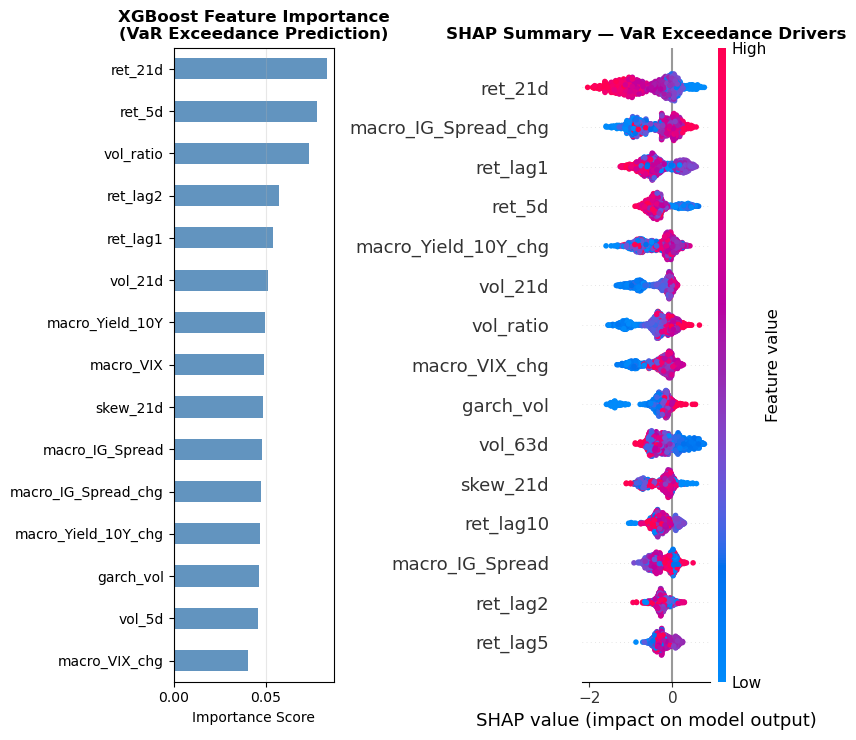


 Features and SHAP saved.


In [6]:
# ── 5. SHAP Feature Importance ────────────────────────────────────────────────
if ML_AVAILABLE:
    explainer   = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test_f)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    fi = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
    fi.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.85)
    axes[0].invert_yaxis()
    axes[0].set_title('XGBoost Feature Importance\n(VaR Exceedance Prediction)', fontweight='bold')
    axes[0].set_xlabel('Importance Score')
    axes[0].grid(alpha=0.3, axis='x')

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_test_f, plot_type='dot', show=False, max_display=15)
    axes[1].set_title('SHAP Summary — VaR Exceedance Drivers', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'fig8_xgb_shap.png'), dpi=150, bbox_inches='tight')
    plt.show()

    feat_df.to_csv(os.path.join(DATA_DIR, 'ml_features.csv'))
    print('\n Features and SHAP saved.')